# Imports

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import Ridge


# Cargar datos

In [3]:
portatiles = pd.read_csv('train.csv')
prediccion = pd.read_csv('test.csv')


# Función de transformación
Definimos una función para aplicar exactamente las mismas transformaciones a train y test

In [4]:
def transformar(df):
    df = df.copy()

    # --- Weight y Ram ---
    df['Weight'] = df['Weight'].str.rstrip('kg').astype(float)
    df['Ram'] = df['Ram'].str.rstrip('GB').astype(int)

    # --- Marcas ---
    marcas = df['Company'].str.get_dummies()
    df = pd.concat([df, marcas], axis=1)
    df = df.drop(columns='Company')

    # --- Tipo de portátil ---
    tipo = df['TypeName'].str.get_dummies()
    df = pd.concat([df, tipo], axis=1)
    df = df.drop(columns='TypeName')
 

    # --- CPU: velocidad ---
    df['velocidad'] = df['Cpu'].str.extract(r'(\d+(?:\.\d+)?)GHz').astype(float)

    # --- CPU: marca ---
    df['cpu_marca'] = df['Cpu'].str.split().str[:1].str.join(' ')

    # --- CPU: gama ---
    gamas = ['Core i3', 'Core i5', 'Core i7', 'Core M', 'Celeron', 'Pentium',
             'Ryzen', 'Atom', 'Xeon', 'A4_Series', 'A6-Series', 'A8-Series',
             'A9-Series', 'A10-Series', 'A12-Series', 'E-Series']
    patron = '|'.join(gamas)
    df['gama'] = df['Cpu'].str.extract(f'({patron})')
    df = df.drop(columns='Cpu')

    # --- Tipos de CPU (get_dummies sobre gama) ---
    tipos_cpu = df['gama'].str.get_dummies()
    df = pd.concat([df, tipos_cpu], axis=1).reset_index(drop=True)
    df = df.drop(columns='gama')
  
    # --- Marca CPU (get_dummies sobre cpu_marca) ---
    marca_cpu = df['cpu_marca'].str.get_dummies().add_prefix('cpu_')
    df = pd.concat([df, marca_cpu], axis=1).reset_index(drop=True)
    df = df.drop(columns='cpu_marca')

    # --- Memory: SSD y memoria total ---
    df['SSD'] = df['Memory'].str.contains('SSD')

    separar = df['Memory'].str.split('+')
    parte1 = separar.str[0]
    parte2 = separar.str[1]

    memoria1 = parte1.str.extract(r'(\d+\.?\d*)\s*(GB|TB)')
    memoria2 = parte2.str.extract(r'(\d+\.?\d*)\s*(GB|TB)')

    memoria1[0] = memoria1[0].astype(float)
    memoria1[0] = memoria1[0].where(memoria1[1] != 'TB', memoria1[0] * 1024)

    memoria2 = memoria2.fillna(0)
    memoria2[0] = memoria2[0].astype(float)
    memoria2[0] = memoria2[0].where(memoria2[1] != 'TB', memoria2[0] * 1024)

    memory = (memoria1[0] + memoria2[0]).rename('total_memory')
    df = pd.concat([df, memory], axis=1).reset_index(drop=True)

    # --- Eliminar columnas que ya no se necesitan ---
    df = df.drop(['laptop_ID', 'Memory', 'Product'], axis=1)

    # --- Sistema operativo ---
    sistemaop = df['OpSys'].str.get_dummies()
    df = pd.concat([df, sistemaop], axis=1).reset_index(drop=True)
    df = df.drop('OpSys', axis=1)

    # --- Pantalla: IPS, Touchscreen, pixels ---
    df['IPS'] = df['ScreenResolution'].str.contains('IPS')
    df['Touchscreen'] = df['ScreenResolution'].str.contains('Touchscreen')
    df['resolucion'] = df['ScreenResolution'].str.extract(r'(\d+x\d+)')
    pixels = df['resolucion'].str.rsplit('x')
    df['pixels'] = pixels.str[0].astype(int) * pixels.str[1].astype(int)
    df = df.drop(['resolucion', 'ScreenResolution'], axis=1)

    # --- GPU: integrada, familias ---
    df['gpu_integrada'] = df['Gpu'].str.contains('Intel')
    familias_gpu = ['AMD Radeon', 'Nvidia GeForce', 'Nvidia Quadro', 'AMD FirePro', 'AMD R17M-M1-70', 'Nvidia GTX']
    patron_gpu = '|'.join(familias_gpu)
    df['Gpu_familia'] = df['Gpu'].str.extract(f'({patron_gpu})')
    familias_dummies = df['Gpu_familia'].str.get_dummies()
    df = pd.concat([df, familias_dummies], axis=1).reset_index(drop=True)
    df = df.drop(['Gpu_familia', 'Gpu'], axis=1)

    return df


# Aplicar transformaciones

In [5]:
portatiles = transformar(portatiles)
prediccion = transformar(prediccion)


# Alinear columnas de train y test
El test puede tener columnas distintas si hay marcas o valores que no aparecen en train

In [6]:
# Columnas de X en train (sin id y sin Price_euros)
features = [c for c in portatiles.columns if c not in ['id', 'Price_euros']]

# Alinear el test para que tenga exactamente las mismas columnas
# Las columnas que falten en test se rellenan con 0
prediccion = prediccion.reindex(columns=['id'] + features, fill_value=0)


# Preparar X e y para entrenar

In [7]:
X = portatiles[features]
y = portatiles['Price_euros']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)


# Escalar

In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Escalar también el test de Kaggle con el mismo scaler
X_kaggle = prediccion[features]
X_kaggle_scaled = scaler.transform(X_kaggle)


# Entrenar modelo y evaluar

In [33]:
modelo = GradientBoostingRegressor(
    max_depth=2,
    n_estimators=100,
    learning_rate=1.0,
    subsample=0.8,
    random_state=42
)

modelo.fit(X_train_scaled, y_train)

y_pred_test = modelo.predict(X_test_scaled)
print('MAE test:', mean_absolute_error(y_test, y_pred_test))
print('MAE train:', mean_absolute_error(y_train, modelo.predict(X_train_scaled)))


MAE test: 203.7983144048233
MAE train: 112.41519933607138


# Predecir sobre test de Kaggle y generar submission

In [34]:
y_kaggle_pred = modelo.predict(X_kaggle_scaled)

submission = pd.DataFrame({
    'id': prediccion['id'],
    'Price_euros': y_kaggle_pred
})

submission.to_csv('submission1.csv', index=False)
print('Submission generada:', submission.shape)
submission.head()


Submission generada: (391, 2)


,id,Price_euros
0,824,1397.146912
1,101,330.830698
2,1157,2004.565864
3,940,1642.580207
4,853,1413.017460


In [ ]:
# Nos quedamos solo con las features que influyan al menos un 1% (son 10-15)
importancias = pd.Series(modelo.feature_importances_, index=X_train.columns)
#importancias.sort_values(ascending=False).head(20)
features_importantes = importancias[importancias > 0.01].index
X_train_reducido = X_train[features_importantes]
X_test_reducido = X_test[features_importantes]

In [ ]:
#Volvemos a escalar
scaler = StandardScaler()
X_train_reducido_scaled = scaler.fit_transform (X_train_reducido)
X_test_reducido_scaled = scaler.transform(X_test_reducido)


In [ ]:
#También en el kaggle
X_kaggle_red = prediccion[features_importantes]
X_kaggle_red_scaled = scaler.transform(X_kaggle)

# Entrenar modelo nuevo y evaluar

In [40]:
# Entrenar modelo y evaluar
gradient_red = GradientBoostingRegressor(max_depth=2,
                                 n_estimators=100,
                                 learning_rate=1.0,
                                 subsample=0.8,
                                 random_state=42)

gradient_red.fit (X_train_reducido_scaled, y_train)

y_pred= gradient_red.predict (X_test_reducido_scaled)
error_gradient_red = mean_absolute_error (y_test, y_pred)
print ('MAE test:', error_gradient_red)
print ('MAE train:', mean_absolute_error (y_train, gradient_red.predict (X_train_reducido_scaled)))

MAE test: 237.92488794408496
MAE train: 141.24555602928027


# Predecir sobre el test y crear fichero

In [41]:
y_kaggle_pred = gradient_red.predict(X_kaggle_scaled)

submission = pd.DataFrame({
    'id': prediccion['id'],
    'Price_euros': y_kaggle_pred
})

submission.to_csv('submission2.csv', index=False)
print('Submission generada:', submission.shape)

Submission generada: (391, 2)


# Regresión lineal

In [43]:
# NO he probado una regresión lineal. 
for alpha in [0.1, 1, 10, 100, 1000]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_reducido_scaled, y_train)
    mae_test = mean_absolute_error(y_test, ridge.predict(X_test_reducido_scaled))
    mae_train = mean_absolute_error(y_train, ridge.predict(X_train_reducido_scaled))
    print(f'alpha={alpha} -> MAE test: {mae_test:.2f} | MAE train: {mae_train:.2f}')

alpha=0.1 -> MAE test: 305.26 | MAE train: 277.55
alpha=1 -> MAE test: 305.21 | MAE train: 277.61
alpha=10 -> MAE test: 304.75 | MAE train: 278.25
alpha=100 -> MAE test: 307.09 | MAE train: 285.13
alpha=1000 -> MAE test: 376.19 | MAE train: 365.84


# Random Forest

In [9]:
# Primero con todas las features
# Tiene mogollón de overfitting
random_baseline = RandomForestRegressor (n_estimators=100,
                                 random_state=42)
random_baseline.fit(X_train_scaled, y_train)

y_pred = random_baseline.predict (X_test_scaled)

error_baseline = mean_absolute_error (y_test, y_pred)
print ('MAE test:', error_baseline)
print ('MAE train:', mean_absolute_error (y_train, random_baseline.predict (X_train_scaled)))

MAE test: 198.07702078064014
MAE train: 73.28545387157882


In [15]:
pesos = pd.Series(random_baseline.feature_importances_, index=X_train.columns)
pesos.sort_values(ascending=False).head(20)

Ram              0.551072
Weight           0.100903
velocidad        0.057555
Notebook         0.043952
pixels           0.034530
Nvidia Quadro    0.031946
Inches           0.020379
SSD              0.019340
total_memory     0.015588
Core i5          0.013980
Workstation      0.011415
Core i7          0.010532
Xeon             0.009639
Windows 7        0.009126
IPS              0.008212
Razer            0.007266
Asus             0.006707
Lenovo           0.004988
AMD Radeon       0.004793
HP               0.004594
dtype: float64

In [22]:
# Nos quedamos solo con las features que influyan al menos un 1% 

features_rf= pesos[pesos > 0.01].index
X_train_reducido = X_train[features_rf] 
X_test_reducido = X_test[features_rf]
#Volvemos a escalar
scaler = StandardScaler()
X_train_reducido_scaled = scaler.fit_transform (X_train_reducido)
X_test_reducido_scaled = scaler.transform(X_test_reducido)

In [23]:
#También sobre el Kaggle
X_kaggle = prediccion[features_rf]
X_kaggle_scaled = scaler.transform(X_kaggle)

In [25]:
random_reducido = RandomForestRegressor (n_estimators=100,
                                 random_state=42)
random_reducido.fit(X_train_reducido_scaled, y_train)

y_pred = random_reducido.predict (X_test_reducido_scaled)

error_rand_reduc = mean_absolute_error (y_test, y_pred)
print ('MAE test:', error_rand_reduc)
print ('MAE train:', mean_absolute_error (y_train, random_reducido.predict (X_train_reducido_scaled)))

MAE test: 222.95090955915518
MAE train: 83.77480500125198


In [ ]:
# Es peor con menos features a las que no hace ni puto caso. El que lo entienda que lo compre

# ENtrenamiento de Kaggle y envío

In [29]:
y_kaggle_pred = random_baseline.predict(X_kaggle_scaled)

submission = pd.DataFrame({
    'id': prediccion['id'],
    'Price_euros': y_kaggle_pred
})

submission.to_csv('submission_randombaseline.csv', index=False)
print('Submission generada:', submission.shape)

Submission generada: (391, 2)


# Ultima prueba. Log 

<Axes: >

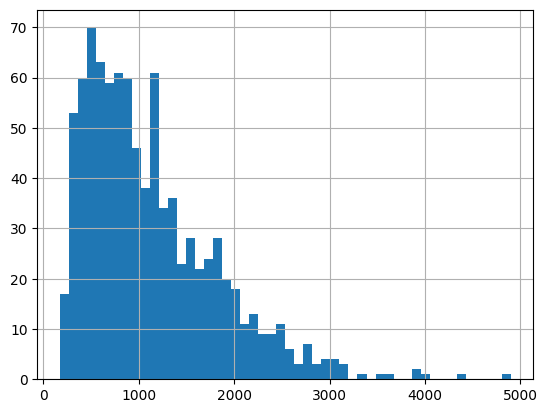

In [30]:
import matplotlib.pyplot as plt
portatiles['Price_euros'].hist(bins=50)

In [33]:
# Hay bastante sesgo a la derecha. Hacemos un log
y_train_log = np.log1p(y_train)
random_baseline.fit (X_train_scaled, y_train_log)

#Escala logarítmica (a los dos para luego poder medir tb el Mae en train)
y_pred_test_log = random_baseline.predict(X_test_scaled)
y_pred_train_log = random_baseline.predict(X_train_scaled)

# Deshacemos para poder medir
pred_test = np.expm1(y_pred_test_log)
pred_train = np.expm1(y_pred_train_log)



# Volver a escala real
y_pred_test = np.expm1(y_pred_test_log)
y_pred_train = np.expm1(y_pred_train_log)

# Calcular MAE real
mae_test = mean_absolute_error(y_test, y_pred_test)
mae_train = mean_absolute_error(y_train, y_pred_train)


In [ ]:
print ('MAE test:', mae_test)
print ('MAE train:', mae_train)

MAE test: 193.28363639026438
MAE train: 75.36456454761175


# Entrenamiento en Kaggle y envío

In [36]:
pred_test_log = random_baseline.predict(X_kaggle_scaled)
# Cuidado que las predicciones están en log. Deshacer
pred_test = np.expm1(pred_test_log)

In [37]:
submission = pd.DataFrame({
    'id': prediccion['id'],
    'Price_euros': pred_test
})

submission.to_csv('submission_log.csv', index=False)
print('Submission generada:', submission.shape)

Submission generada: (391, 2)
